### **LoRA con PyTorch**

LoRA (Low-Rank Adaptation) es una técnica de **afinado de parámetros eficientes** para grandes modelos de lenguaje (LLM) que permite adaptar un modelo preentrenado a una nueva tarea sin necesidad de actualizar o almacenar todos sus billones de parámetros. A continuación se detalla algunas características importantes:


- `Eficiencia en las actualizaciones de parámetros:` LoRA introduce solo una pequeña fracción de parámetros adicionales comparado con el número total de parámetros de un modelo grande. Esto hace que el proceso de entrenamiento sea más rápido y menos intensivo en recursos, ya que se necesitan actualizar menos parámetros durante la retropropagación.

- `Preservación del conocimiento preentrenado:` Al mantener la mayoría de los pesos del modelo fijos y ajustarlos únicamente mediante matrices de baja dimensión, LoRA ayuda a conservar las ricas representaciones que el modelo aprendió durante el preentrenamiento. Esto es especialmente beneficioso para tareas que no requieren desviaciones drásticas del comportamiento aprendido en el preentrenamiento.

- `Personalización para tareas específicas:` A pesar de las actualizaciones mínimas, los cambios introducidos por LoRA son lo suficientemente significativos como para adaptar el modelo a tareas concretas. Esto permite afinar modelos grandes en tareas especializadas sin necesidad de un reentrenamiento extenso.

- `Reducción del sobreajuste:` Debido a que solo se adaptan un número limitado de parámetros, el riesgo de sobreajuste es menor en comparación con el ajuste fino completo del modelo, especialmente al adaptar el modelo a conjuntos de datos más pequeños.

- `Escalabilidad:` LoRA escala bien con el tamaño del modelo. A medida que los modelos se vuelven más grandes, el incremento relativo en el número de parámetros introducidos por LoRA se hace aún más pequeño, lo que lo convierte en una opción especialmente atractiva para adaptar modelos muy grandes.

- `Compatibilidad y simplicidad:` El método puede aplicarse fácilmente a diferentes tipos de redes neuronales, especialmente a aquellas basadas en la arquitectura Transformer. No requiere cambios importantes en la arquitectura existente, lo que simplifica su integración en pipelines ya establecidos.



#### **Adaptación de baja dimensión (LoRA)**

PyTorch y la librería Hugging Face ofrecen herramientas sólidas para la manipulación de modelos con LoRA, pero no son muy intuitivas. 

En esta sección, profundizaremos en la construcción de una implementación de LoRA (Low-Rank Adaptation) desde cero usando PyTorch. LoRA es un método general, pero se aplica comúnmente a la capa de atención. Por simplicidad, en este cuaderno lo aplicaremos a una red neuronal. Esta decisión se toma porque acceder a los parámetros de *atención* en el módulo Encoder de PyTorch puede resultar complejo.

#### **LoRA**

1. Para cualquier capa arbitraria de una red, tienes el modelo con parámetros preentrenados $W_0$, que son los parámetros del modelo. Si solo consideras los parámetros de atención de cada capa, al menos $4 \times m \times n$ por capa. En muchos modelos, esto puede alcanzar billones de parámetros aprendibles. Cada vez que afinamos con un nuevo conjunto de datos, tendrías que almacenar billones de parámetros.

2. $\Delta W$ representa dos matrices $B$ y $A$, donde $B$ y $A$ están constriñidas de manera que $B \in \mathbb{R}^{m \times r}$, $A \in \mathbb{R}^{r \times n}$, y $r \le \min(m,n)$. El número total de parámetros en $A$ y $B$ es mucho menor que en $W_1$ y mucho más fácil de almacenar.

$$
W_1 \approx W_0 + \Delta W = W_0 + BA
$$

3. Para entrenar y predecir, en el pase hacia adelante $W_0$ se mantiene constante:

$$
h = W_0 x + BAx
$$

Para escalar $\Delta W$ por $\tfrac{\alpha'}{r}$, donde $\alpha$ es una constante relacionada con $r$, ajustar $\alpha'$ es similar a sintonizar la tasa de aprendizaje si la inicialización está correctamente escalada. Por lo tanto, se fija $\alpha'$ igual al primer $r$ que se prueba y no se sintoniza más; simplemente se usa $\alpha$. Este escalado reduce la necesidad de retocar hiperparámetros. La forma final es:

$$
h = W_0 x + \frac{\alpha'}{r} BAx = W_0 x + \alpha\,BAx
$$

El siguiente ejemplo ilustra el proceso.

$
W_0 + BA = 
\begin{bmatrix}
w_{11} & w_{12} & w_{13} & w_{14} \\\\\\\\\\\\\\\\\\\\
w_{21} & w_{22} & w_{23} & w_{24} \\\\\\
w_{31} & w_{32} & w_{33} & w_{34} \\\\\\
w_{41} & w_{42} & w_{43} & w_{44} \\\\\\
\end{bmatrix} +
\begin{bmatrix}
a_1 \\\\\\
a_2 \\\\\\
a_3 \\\\\\
a_4 \\\\\\
\end{bmatrix}
\begin{bmatrix}
b_1 & b_2 & b_3 & b_4 \\\\
\end{bmatrix}
$

Esto muestra el producto de las matrices $A$ y $B$, denotado $AB$, que se puede sumar a $W_0$. Sin embargo, la matriz resultante $W_0 + AB$ está limitada según las dimensiones de $A$ y $B$, debido al concepto de rango (rank).

#### **Rango**

El rango de una matriz es el número de dimensiones en las que "viven" sus filas (o columnas). 

Una matriz cuadrada se dice de **rango completo** (full rank) si su rango es igual al número de filas o columnas. Hagamos esta idea más intuitiva con un ejemplo.

In [1]:
from torch.utils.data import DataLoader
from collections import OrderedDict
from types import SimpleNamespace


In [2]:
from sympy import Matrix, init_printing,Symbol

from numpy.linalg import qr,eig,inv,matrix_rank,inv, norm
from scipy.linalg import null_space
from sympy import Matrix, init_printing,Symbol
init_printing()

/tmp/ipykernel_15567/3800926399.py:4: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.linalg import null_space


In [3]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix_and_subspace(F):
    # Asegura de que F tenga 3 filas para poder visualizar en 3D.
    assert F.shape[0] == 3, "La matriz F debe tener 3 filas para visualización en 3D."
    
    # Crea una figura y un eje 3D
    ax = plt.figure().add_subplot(projection='3d')
    
    # Para cada columna de F, dibujar un vector desde el origen
    for i in range(F.shape[1]):
        ax.quiver(
            0, 0, 0,                   # origen del vector
            F[0, i], F[1, i], F[2, i], # componentes del vector
            color='blue',
            arrow_length_ratio=0.1,
            label=f'Columna {i+1}'     # etiqueta para la leyenda
        )

    # Si F tiene exactamente 2 columnas, dibujar el plano que ellas generan
    if F.shape[1] == 2:
        # Calcula el vector normal al plano generado por las dos columnas
        normal_vector = np.cross(F[:, 0], F[:, 1])
        
        # Crea una malla de puntos en XY para dibujar la superficie del plano
        xx, yy = np.meshgrid(
            np.linspace(-3, 3, 10),
            np.linspace(-3, 3, 10)
        )
        # Ecuación del plano: normal · [x, y, z] = 0  =>  z = ...
        if normal_vector[2] != 0:
            zz = (-normal_vector[0] * xx - normal_vector[1] * yy) / normal_vector[2]
        else:
            zz = np.zeros_like(xx)
        
        # Dibuja la superficie del plano con transparencia
        ax.plot_surface(xx, yy, zz, alpha=0.5, color='green', label='Plano generado')

    # Configura límites de los ejes
    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_zlim([-3, 3])
    
    # Etiquetas de los ejes
    ax.set_xlabel('$x_{1}$')
    ax.set_ylabel('$x_{2}$')
    ax.set_zlabel('$x_{3}$')
    
    # Muestra la figura
    plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_matrix_and_subspace(F):
    # Asegura de que F tenga 3 filas para poder visualizar en 3D.
    assert F.shape[0] == 3, "La matriz F debe tener 3 filas para visualización en 3D."
    
    # Crea una figura y un eje 3D
    ax = plt.figure().add_subplot(projection='3d')
    
    # Para cada columna de F, dibujar un vector desde el origen
    for i in range(F.shape[1]):
        ax.quiver(
            0, 0, 0,                   # origen del vector
            F[0, i], F[1, i], F[2, i], # componentes del vector
            color='blue',
            arrow_length_ratio=0.1,
            label=f'Columna {i+1}'     # etiqueta para la leyenda
        )

    # Si F tiene exactamente 2 columnas, dibujar el plano que ellas generan
    if F.shape[1] == 2:
        # Calcula el vector normal al plano generado por las dos columnas
        normal_vector = np.cross(F[:, 0], F[:, 1])
        
        # Crea una malla de puntos en XY para dibujar la superficie del plano
        xx, yy = np.meshgrid(
            np.linspace(-3, 3, 10),
            np.linspace(-3, 3, 10)
        )
        # Ecuación del plano: normal · [x, y, z] = 0  =>  z = ...
        if normal_vector[2] != 0:
            zz = (-normal_vector[0] * xx - normal_vector[1] * yy) / normal_vector[2]
        else:
            zz = np.zeros_like(xx)
        
        # Dibuja la superficie del plano con transparencia
        ax.plot_surface(xx, yy, zz, alpha=0.5, color='green', label='Plano generado')

    # Configura límites de los ejes
    ax.set_xlim([-3, 3])
    ax.set_ylim([-3, 3])
    ax.set_zlim([-3, 3])
    
    # Etiquetas de los ejes
    ax.set_xlabel('$x_{1}$')
    ax.set_ylabel('$x_{2}$')
    ax.set_zlabel('$x_{3}$')
    
    # Muestra la figura
    plt.show()


En el contexto de Low-Rank Adaptation  (LoRA), donde $B \in \mathbb{R}^{d \times r}$, la matriz $B$:

In [4]:
import torch
B=torch.tensor([[1,0],[0,1],[0,0]]).numpy()

Matrix(B)

⎡1  0⎤
⎢    ⎥
⎢0  1⎥
⎢    ⎥
⎣0  0⎦

Esta matriz de $3 \times 2$ tiene columnas que generan un subespacio bidimensional en $\mathbb{R}^3$. Específicamente, las columnas de $B$ son:

- $\mathbf{b}_1 = \begin{bmatrix} 1 \\\\\\\\\\\\\\\\\\ 0 \\ 0 \end{bmatrix}$
- $\mathbf{b}_2 = \begin{bmatrix} 0 \\\\ 1 \\ 0 \end{bmatrix}$

Estos vectores columna son los vectores de la base estándar para el plano $xy$ en $\mathbb{R}^3$ y, por lo tanto, generan el plano $xy$ mostrado en verde en la imagen siguiente. Multiplicar cualquiera de estos vectores columna (en azul) por un escalar siempre resulta en un punto que queda en ese mismo plano.

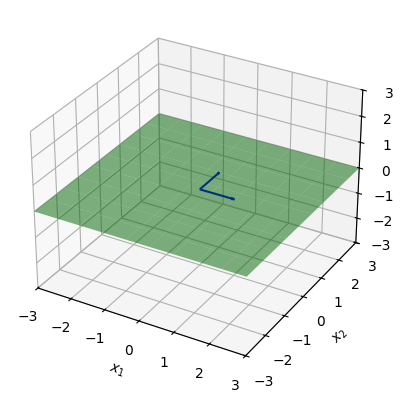

In [5]:
plot_matrix_and_subspace(B)

En este escenario, los vectores, a pesar de tener cada uno tres componentes, pueden alcanzar cualquier punto del plano verde bidimensional representado en la imagen. Estos vectores abarcan el plano verde, que reside dentro de un subespacio bidimensional. 

La dimensión de este subespacio, también conocida como su "rango", es dos, lo que corresponde a la dimensionalidad del plano. Si el rango fuera tres, cualquier punto en el espacio 3D podría alcanzarse mediante alguna combinación de las columnas de $𝐵$. El rango de una matriz se puede determinar usando la función `matrix_rank` proporcionada por NumPy.

In [6]:
matrix_rank(B)

np.int64(2)

Aquí, trazas una matriz diferente donde la matriz abarca un plano distinto, pero el rango sigue siendo dos.

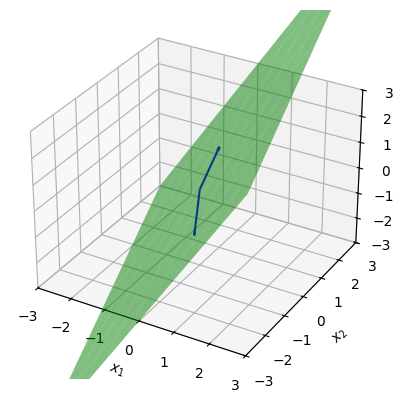

rank de B 2


In [7]:
B_=torch.tensor([[1,0],[-2,1],[0,1]]).numpy()
plot_matrix_and_subspace(B_)
print("rank de B",matrix_rank(B_))

In [ ]:
matrix_rank(B)

Aquí presentamos la matriz `A`. El rango de esta matriz también es dos.

In [8]:
A=torch.tensor([[1,1,-1,1,0],[-2,2,2,0,1]]).numpy()
Matrix(A)

⎡1   1  -1  1  0⎤
⎢               ⎥
⎣-2  2  2   0  1⎦

In [9]:
matrix_rank(A)

np.int64(2)


Para las matrices $C = BA$, si $B$ y $A$ tienen ambas rango $r$:

In [10]:
C=B@A
Matrix(C)


⎡1   1  -1  1  0⎤
⎢               ⎥
⎢-2  2  2   0  1⎥
⎢               ⎥
⎣0   0  0   0  0⎦

Las columnas de $C$ tendrán el mismo rango que $B$. Además, el espacio generado por las columnas de $C$ será el mismo que el generado por las columnas de $B$.

rank de C 2


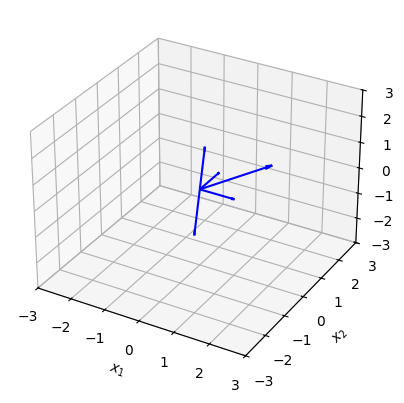

In [11]:
print("rank de C",matrix_rank(C))
plot_matrix_and_subspace(C)

### **Entendiendo LoRA in PyTorch**

LoRA (Low-Rank Adaptation) es relativamente sencillo de inicializar en PyTorch. Se inicializa LoRA con las dimensiones de la entrada (`in_dim`), $m$, la salida (`out_dim`), $n$, un rango (`rank`), $r$, y un factor de escala `alpha`. Los parámetros se inicializan de la siguiente forma:

```
self.A = torch.nn.Parameter(torch.randn(in_dim, rank) * std_dev)
self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
```

El uso de `nn.Parameter` hace que estos valores sean parámetros aprendibles.

En la función forward, LoRA usa la notación $BAx$. En PyTorch, el vector de entrada es una fila, por lo que la salida se convierte en $x^TA^TB^T$; a partir de ahora omitiremos la transposición. El paso forward se implementa como:

```
x = self.alpha * (x @ self.A @ self.B)
```

El uso de `nn.Parameter` hace que estos valores sean parámetros aprendibles.


In [ ]:
class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha):
        super().__init__()
        std_dev = 1 / torch.sqrt(torch.tensor(rank).float())
        self.A = torch.nn.Parameter(torch.randn(in_dim, rank) * std_dev)
        
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim))
        self.alpha = alpha

    def forward(self, x):
        x = self.alpha * (x @ self.A @ self.B)
        return x

Esta clase `LinearWithLoRA` copia el modelo lineal original y crea un objeto `LoRALayer`.

```
self.linear = linear.to(device)
self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        ).to(device)
```

Luego, en el método forward aplica tanto el modelo lineal original como el modelo LoRA a la entrada `x` y los suma: `self.linear(x) + self.lora(x)`. Esto corresponde a:

$x W_0 + x A B$

In [ ]:
class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(
            linear.in_features, linear.out_features, rank, alpha
        )

    def forward(self, x):
        return self.linear(x) + self.lora(x)

### **Configuración adicionales**

#### **Importar las librerías requeridas**

El siguiente bloque importa todas las librerías necesarias:


In [ ]:
from tqdm import tqdm
import time
import numpy as np
import pandas as pd
from itertools import accumulate
import matplotlib.pyplot as plt
import math
import os
import io
import re
import pickle
import random

import torch
torch.set_num_threads(1)
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torch.utils.data.dataset import random_split
from torch.nn.utils.rnn import pad_sequence
from IPython.display import Markdown as md

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# También puedes usar esta sección para suprimir las advertencias generadas por tu código:
def warn(*args, **kwargs):
    pass

import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

#### **Funciones auxiliares**

El siguiente código muestra algunas funciones de ayuda para graficar, guardar y cargar archivos. Estas funciones no son el foco principal del cuaderno, pero debes ejecutar estas celdas para poder usarlas más adelante.


In [ ]:
def plot(COST,ACC):
    """
    Grafica la evolución de la pérdida total y la precisión por época.

    Parámetros:
        COST (list): Lista con el valor de la pérdida total en cada época.
        ACC (list): Lista con la precisión en cada época.
    """

    fig, ax1 = plt.subplots()
    color = 'tab:red'
    ax1.plot(COST, color=color)
    ax1.set_xlabel('epoca', color=color)
    ax1.set_ylabel('Perdida total', color=color)
    ax1.tick_params(axis='y', color=color)

    ax2 = ax1.twinx()
    color = 'tab:blue'
    ax2.set_ylabel('accuracy', color=color)  
    ax2.plot(ACC, color=color)
    ax2.tick_params(axis='y', color=color)
    fig.tight_layout() 

    plt.show()

In [ ]:
def save_list_to_file(lst, filename):
    """
    Guarda una lista en un archivo usando serialización con pickle.

    Parámetros:
        lst (list): La lista que se guardará.
        filename (str): El nombre del archivo donde se guardará la lista.

    Retorna:
        None
    """
    with open(filename, 'wb') as file:
        pickle.dump(lst, file)

def load_list_from_file(filename):
    """
    Carga una lista desde un archivo usando deserialización con pickle.

    Parámetros:
        filename (str): El nombre del archivo desde el cual se cargará la lista.

    Retorna:
        list: La lista cargada.
    """
    with open(filename, 'rb') as file:
        loaded_list = pickle.load(file)
    return loaded_list

#### **Pipeline de datos**

**Tokenizador**

In [ ]:
_TOKEN_PATTERN = re.compile(r"[A-Za-z0-9']+")

In [ ]:
def basic_english_tokenizer(text):
    text = text.lower()
    text = re.sub(r"<br\s*/?>", " ", text)
    return _TOKEN_PATTERN.findall(text)

tokenizer = basic_english_tokenizer

#### **Colección contextual de ejemplos: versión más realista**

La versión anterior era útil para explicar LoRA, pero el corpus era demasiado pequeño y demasiado fácil: el modelo podía aprender atajos léxicos como `good -> positivo` y `bad -> negativo`.  
Para evitar una exactitud artificial de 100%, separamos el experimento en dos dominios:

* **dominio fuente**: ejemplos simples, usados para entrenar el modelo base;
* **dominio objetivo**: ejemplos con contraste, negación y frases ambiguas, usados para adaptar con LoRA y evaluar generalización.

Esto produce una comparación más honesta: el modelo base no se evalúa solo en frases casi idénticas a las de entrenamiento.


In [ ]:
source_positive = [
    (1, "good movie with good acting and a good ending"),
    (1, "excellent film with strong acting and a warm ending"),
    (1, "great story good pacing and enjoyable characters"),
    (1, "pleasant movie with charming scenes and positive energy"),
    (1, "this film felt good bright and entertaining"),
    (1, "good script good cast and satisfying ending"),
    (1, "the movie was fun emotional and very good"),
    (1, "excellent direction and good performances throughout"),
    (1, "a rewarding film with good humor and heart"),
    (1, "good acting and a beautiful hopeful message"),
    (1, "great movie with good dialogue and good rhythm"),
    (1, "this was a good film with a strong ending"),
]

source_negative = [
    (0, "bad movie with bad acting and a bad ending"),
    (0, "awful film with weak acting and an empty ending"),
    (0, "poor story bad pacing and annoying characters"),
    (0, "joyless movie with flat scenes and negative energy"),
    (0, "this film felt bad dull and exhausting"),
    (0, "bad script bad cast and frustrating ending"),
    (0, "the movie was boring lifeless and very bad"),
    (0, "awful direction and bad performances throughout"),
    (0, "a disappointing film with bad humor and no heart"),
    (0, "bad acting and a hollow miserable message"),
    (0, "poor movie with bad dialogue and weak rhythm"),
    (0, "this was a bad film with a weak ending"),
]

source_valid = [
    (1, "excellent cast and enjoyable rhythm"),
    (1, "good direction with charming characters"),
    (0, "awful cast and boring rhythm"),
    (0, "bad direction with weak characters"),
]

target_adapt_train = [
    (1, "not a bad movie at all despite a slow start"),
    (1, "the plot is simple but the ending works well"),
    (1, "the acting is uneven yet the film has heart"),
    (1, "not perfect but still enjoyable and warm"),
    (1, "the story takes time but becomes rewarding"),
    (1, "some scenes are dull but the message is hopeful"),
    (1, "slow pacing but emotionally satisfying"),
    (1, "weak opening yet the characters become charming"),
    (1, "not flawless but the film remains honest"),
    (1, "simple visuals but a warm and uplifting story"),
    (1, "uneven dialogue yet the final act is moving"),
    (1, "minor flaws aside the experience is rewarding"),
    (0, "not a good movie even with a famous cast"),
    (0, "the opening is promising but the film becomes boring"),
    (0, "good visuals cannot hide a weak script"),
    (0, "the acting is strong but the story feels empty"),
    (0, "the soundtrack is pleasant yet the movie is disappointing"),
    (0, "not awful at first but ultimately tiring"),
    (0, "beautiful camera work cannot save the dull story"),
    (0, "good cast but no emotional payoff"),
    (0, "promising premise yet the film turns hollow"),
    (0, "strong performances but a confusing weak plot"),
    (0, "pleasant moments aside the movie is exhausting"),
    (0, "not terrible visually but still disappointing"),
]

target_valid = [
    (1, "slow but emotionally satisfying in the final act"),
    (1, "not bad because the characters feel honest"),
    (1, "uneven pacing but a beautiful hopeful message"),
    (0, "good cast but the movie never becomes interesting"),
    (0, "not good because the ending feels hollow"),
    (0, "pleasant music but a confusing and weak story"),
]

target_test = [
    (1, "not a bad film because the ending is surprisingly warm"),
    (1, "the first half is dull but the final act is moving"),
    (1, "weak dialogue aside the movie has real heart"),
    (1, "not perfect yet it remains charming and honest"),
    (1, "the pacing is slow but the conclusion is rewarding"),
    (1, "the visuals are simple but the story is uplifting"),
    (1, "some scenes feel flat yet the characters are enjoyable"),
    (1, "despite flaws the film leaves a hopeful message"),
    (1, "uneven at first but emotionally satisfying later"),
    (1, "not flawless but the characters become warm"),
    (0, "not a good film because the ending is empty"),
    (0, "the cast is strong but the script is poor"),
    (0, "beautiful scenes cannot save the boring story"),
    (0, "the movie starts well but becomes exhausting"),
    (0, "good music does not fix the weak rhythm"),
    (0, "not awful visually but emotionally hollow"),
    (0, "the performances are decent yet the film is disappointing"),
    (0, "pleasant moments aside the experience is tiring"),
    (0, "promising start but the plot becomes confusing"),
    (0, "strong acting cannot hide the hollow message"),
]

# El vocabulario se construye sin usar target_test para no contaminar la evaluación.
contextual_samples = source_positive + source_negative + source_valid + target_adapt_train + target_valid

class ContextualTextDataset(Dataset):
    def __init__(self, samples):
        self.samples = list(samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


El siguiente código crea el conjunto de datos y muestra algunos ejemplos:

In [ ]:
full_dataset = ContextualTextDataset(contextual_samples)

for i in range(3):
    print(full_dataset[i])

for i in range(len(full_dataset) - 3, len(full_dataset)):
    print(full_dataset[i])

Definimos el mapeo de etiquetas para interpretar las predicciones:

In [ ]:
label_map = {0: "negative review", 1: "positive review"}
num_class = len(set(label for label, _ in full_dataset))
num_class

El tokenizador divide cada texto en tokens y luego construiremos un vocabulario sencillo a partir del propio corpus:

In [ ]:
def yield_tokens(data_iter):
    for _, text in data_iter:
        yield tokenizer(text)

class SimpleVocab:
    def __init__(self, token_to_idx):
        self.token_to_idx = dict(token_to_idx)
        self.default_index = 0

    def set_default_index(self, index):
        self.default_index = index

    def __getitem__(self, token):
        return self.token_to_idx[token]

    def __call__(self, tokens):
        return [self.token_to_idx.get(token, self.default_index) for token in tokens]

    def __len__(self):
        return len(self.token_to_idx)

def build_vocab_from_iterator(iterator, specials=("<unk>", "<pad>")):
    token_to_idx = OrderedDict()
    for token in specials:
        if token not in token_to_idx:
            token_to_idx[token] = len(token_to_idx)

    for tokens in iterator:
        for token in tokens:
            if token not in token_to_idx:
                token_to_idx[token] = len(token_to_idx)
    return SimpleVocab(token_to_idx)

vocab = build_vocab_from_iterator(yield_tokens(full_dataset))
vocab.set_default_index(vocab["<unk>"])

Contemos el número de palabras en el vocabulario:

In [ ]:
vocab_size = len(vocab)
vocab_size

Probemos la función `vocab`:

In [ ]:
vocab(["movie", "excellent", "unknown_token"])

#### **División del conjunto de datos**

La división se hace por propósito experimental, no con una partición aleatoria simple:

* `train_samples`: entrenamiento del modelo base en el dominio fuente.
* `valid_samples`: validación del modelo base en el dominio fuente.
* `lora_train_samples`: pocos ejemplos del dominio objetivo para adaptar LoRA.
* `lora_valid_samples`: validación de LoRA.
* `test_samples`: prueba final del dominio objetivo; no se usa para construir el vocabulario ni para entrenar.


In [ ]:
train_samples = source_positive + source_negative
valid_samples = source_valid

lora_train_samples = target_adapt_train
lora_valid_samples = target_valid

test_samples = target_test

rng = random.Random(SEED)
rng.shuffle(train_samples)
rng.shuffle(valid_samples)
rng.shuffle(lora_train_samples)
rng.shuffle(lora_valid_samples)
rng.shuffle(test_samples)

train_dataset = ContextualTextDataset(train_samples)
valid_dataset = ContextualTextDataset(valid_samples)
lora_train_dataset = ContextualTextDataset(lora_train_samples)
lora_valid_dataset = ContextualTextDataset(lora_valid_samples)
test_dataset = ContextualTextDataset(test_samples)

len(train_dataset), len(valid_dataset), len(lora_train_dataset), len(lora_valid_dataset), len(test_dataset)


Ahora el conjunto de prueba tiene más ejemplos y contiene casos con negación, contraste y cambio de dominio.  
Por eso un 100% ya no debería aparecer salvo que el modelo realmente generalice muy bien.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

#### **Cargador de datos**

El pipeline de texto tokeniza y convierte cada oración en índices del vocabulario.

In [ ]:
def text_pipeline(x):
    return vocab(tokenizer(x))

La función `collate_batch` toma un lote de ejemplos, convierte cada texto en índices y rellena las secuencias para que tengan el mismo largo.

In [ ]:
from torch.nn.utils.rnn import pad_sequence

PAD_IDX = vocab["<pad>"]

def collate_batch(batch):
    label_list, text_list = [], []
    for _label, _text in batch:
        label_list.append(_label)
        text_tensor = torch.tensor(text_pipeline(_text), dtype=torch.int64)
        text_list.append(text_tensor)

    label_list = torch.tensor(label_list, dtype=torch.int64)
    text_list = pad_sequence(text_list, batch_first=True, padding_value=PAD_IDX)

    return label_list.to(device), text_list.to(device)

Convertimos las particiones en `DataLoader`:

In [ ]:
BATCH_SIZE = 8

train_dataloader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
valid_dataloader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)
lora_train_dataloader = DataLoader(
    lora_train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_batch
)
lora_valid_dataloader = DataLoader(
    lora_valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)
test_dataloader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_batch
)


Comprobemos la forma de un lote:

In [ ]:
label, sequence = next(iter(valid_dataloader))
label, sequence.shape

#### **Red neuronal**

Definimos un clasificador de texto sencillo con:

* una capa de embedding entrenable,
* una capa lineal oculta con activación ReLU,
* una capa lineal de salida.

Usaremos una representación promedio de los tokens de entrada.

In [ ]:
from torch import nn
import torch

EMBED_DIM = 64

class TextClassifier(nn.Module):
    def __init__(self, num_classes, freeze=False):
        super(TextClassifier, self).__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=EMBED_DIM,
            padding_idx=PAD_IDX
        )
        self.embedding.weight.requires_grad = not freeze
        self.fc1 = nn.Linear(in_features=EMBED_DIM, out_features=128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(in_features=128, out_features=num_classes)

    def forward(self, x):
        mask = (x != PAD_IDX).unsqueeze(-1)
        embedded = self.embedding(x)
        masked_embedded = embedded * mask
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = masked_embedded.sum(dim=1) / lengths
        hidden = self.relu(self.fc1(pooled))
        logits = self.fc2(hidden)
        return logits

#### **Entrenamiento del modelo base**

In [ ]:
modelo = TextClassifier(num_classes=2, freeze=False).to(device)
modelo

In [ ]:
modelo.eval()
predicted_label = modelo(sequence)
predicted_label.shape

La siguiente función `predict` recibe un texto y devuelve la etiqueta estimada:

In [ ]:
def predict(text, text_pipeline, modelo):
    with torch.no_grad():
        text = torch.unsqueeze(torch.tensor(text_pipeline(text)), 0).to(device)
        modelo.to(device)
        output = modelo(text)
        return label_map[output.argmax(1).item()]

In [ ]:
predict("the movie was warm and entertaining", text_pipeline, modelo)

Podemos crear funciones para evaluar el modelo.  
La primera conserva la interfaz simple del cuaderno; la segunda devuelve un reporte más honesto con número de aciertos, total, matriz de confusión e intervalo aproximado de Wilson al 95%.


In [ ]:
def evaluate(dataloader, modelo, device):
    modelo.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for label, text in dataloader:
            outputs = modelo(text)
            _, predicted = torch.max(outputs.data, 1)
            total += label.size(0)
            correct += (predicted == label).sum().item()
    accuracy = 100 * correct / total
    return accuracy


def wilson_interval(correct, total, z=1.96):
    if total == 0:
        return 0.0, 0.0
    p = correct / total
    denom = 1 + z**2 / total
    centre = p + z**2 / (2 * total)
    margin = z * math.sqrt((p * (1 - p) + z**2 / (4 * total)) / total)
    low = (centre - margin) / denom
    high = (centre + margin) / denom
    return 100 * low, 100 * high


def evaluate_report(dataloader, modelo, device, label_names=None):
    modelo.eval()
    correct = 0
    total = 0
    rows = []
    confusion = torch.zeros(2, 2, dtype=torch.int64)

    with torch.no_grad():
        for label, text in dataloader:
            outputs = modelo(text)
            probs = torch.softmax(outputs, dim=1)
            predicted = outputs.argmax(1)

            total += label.size(0)
            correct += (predicted == label).sum().item()

            for y_true, y_pred, confidence in zip(
                label.cpu().tolist(),
                predicted.cpu().tolist(),
                probs.max(dim=1).values.cpu().tolist()
            ):
                confusion[y_true, y_pred] += 1
                rows.append({
                    "true": label_names.get(y_true, y_true) if label_names else y_true,
                    "predicted": label_names.get(y_pred, y_pred) if label_names else y_pred,
                    "confidence": round(float(confidence), 4),
                    "correct": y_true == y_pred,
                })

    accuracy = 100 * correct / total
    ci_low, ci_high = wilson_interval(correct, total)

    return {
        "accuracy": accuracy,
        "correct": correct,
        "total": total,
        "ci95_low": ci_low,
        "ci95_high": ci_high,
        "confusion_matrix": confusion,
        "details": rows,
    }


def print_report(name, report):
    print(f"{name}: {report['accuracy']:.2f}% "
          f"({report['correct']}/{report['total']}) "
          f"IC95% Wilson: [{report['ci95_low']:.2f}%, {report['ci95_high']:.2f}%]")
    print("Matriz de confusión [filas=real, columnas=predicho]:")
    print(report["confusion_matrix"])


Antes de entrenar, el rendimiento del modelo suele estar cerca del azar:

In [ ]:
evaluate(valid_dataloader, modelo, device)

### **Entrenamiento**

Definimos una función de entrenamiento que guarda el mejor modelo y registra pérdida y exactitud por época.

In [ ]:
def train_model(modelo, optimizer, criterion, train_dataloader, valid_dataloader, epochs=20, model_name="mi_modelo"):
    cum_loss_list = []
    acc_epoch = []
    best_acc = 0.0

    for epoch in tqdm(range(1, epochs + 1)):
        modelo.train()
        cum_loss = 0.0

        for label, text in train_dataloader:
            optimizer.zero_grad()
            predicted_label = modelo(text)
            loss = criterion(predicted_label, label)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(modelo.parameters(), 0.5)
            optimizer.step()
            cum_loss += loss.item()

        acc_val = evaluate(valid_dataloader, modelo, device)
        cum_loss_list.append(cum_loss)
        acc_epoch.append(acc_val)

        if acc_val >= best_acc:
            best_acc = acc_val
            torch.save(modelo.state_dict(), f"{model_name}.pth")

    save_list_to_file(cum_loss_list, f"{model_name}_loss.pkl")
    save_list_to_file(acc_epoch, f"{model_name}_acc.pkl")

    return cum_loss_list, acc_epoch

Usaremos `Adam` con una tasa de aprendizaje moderada para este corpus pequeño.

In [ ]:
LR = 0.02

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(modelo.parameters(), lr=LR)

Entrenamos el modelo base:

In [ ]:
model_name = "model_contextual_base"
cum_loss_list, acc_epoch = train_model(
    modelo, optimizer, criterion, train_dataloader, valid_dataloader, epochs=30, model_name=model_name
)

modelo.load_state_dict(torch.load(f"{model_name}.pth", map_location=device))
modelo.eval()

Grafiquemos la pérdida y la exactitud por época:

In [ ]:
plot(cum_loss_list, acc_epoch)

Evaluamos el modelo base sobre la prueba objetivo.  
Esta prueba es más exigente que la validación fuente porque contiene negación y contraste.


In [ ]:
baseline_report = evaluate_report(test_dataloader, modelo, device, label_map)
baseline_test_acc = baseline_report["accuracy"]

print_report("Modelo base en prueba objetivo", baseline_report)
pd.DataFrame(baseline_report["details"]).head(10)


Guardamos una copia de los pesos base para reutilizarlos en la fase de adaptación con LoRA.

In [ ]:
base_state_dict = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
print(f"Exactitud del modelo base en prueba objetivo: {baseline_test_acc:.2f}%")


### **Aplicando LoRA**

Ahora reutilizaremos el modelo base ya entrenado y añadiremos una adaptación LoRA sobre la capa lineal oculta `fc1`.  
A diferencia de la versión anterior, LoRA se entrena con pocos ejemplos del **dominio objetivo**. Esto permite observar si la adaptación de bajo rango corrige parte del cambio de distribución sin reentrenar todos los parámetros.


In [ ]:
model_lora = TextClassifier(num_classes=2, freeze=False).to(device)
model_lora.load_state_dict(base_state_dict)

for param in model_lora.parameters():
    param.requires_grad = False

# Un rango algo mayor ayuda en el conjunto objetivo sin convertirlo en fine-tuning completo.
model_lora.fc1 = LinearWithLoRA(model_lora.fc1, rank=8, alpha=1.0).to(device)

for param in model_lora.fc1.lora.parameters():
    param.requires_grad = True

# Se permite adaptar la capa de salida, pero se mantiene congelado el embedding y el resto de la red.
for param in model_lora.fc2.parameters():
    param.requires_grad = True

model_lora


Observa que ahora la adaptación LoRA vive dentro de `model_lora.fc1.lora`.

In [ ]:
model_lora.fc1

Podemos contar cuántos parámetros quedan entrenables:

In [ ]:
def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def count_all_parameters(model):
    return sum(p.numel() for p in model.parameters())

count_trainable_parameters(model_lora), count_all_parameters(model_lora)

El entrenamiento de LoRA usa solo:

* las matrices `A` y `B` de LoRA,
* la capa de salida `fc2`,
* los pocos ejemplos del dominio objetivo.

El modelo base no se reentrena completo.


In [ ]:
LR = 0.01
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    [p for p in model_lora.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=1e-4
)


Entrenamos la versión con LoRA:

In [ ]:
model_name = "model_lora_contextual_realistic"
lora_loss_list, lora_acc_epoch = train_model(
    model_lora,
    optimizer,
    criterion,
    lora_train_dataloader,
    lora_valid_dataloader,
    epochs=30,
    model_name=model_name
)

model_lora.load_state_dict(torch.load(f"{model_name}.pth", map_location=device))
model_lora.eval()


Veamos la evolución del entrenamiento con LoRA:

In [ ]:
plot(lora_loss_list, lora_acc_epoch)

Comparemos la exactitud final en la misma prueba objetivo.  
No buscamos un 100%; buscamos una mejora plausible y un reporte que permita ver errores.


In [ ]:
lora_report = evaluate_report(test_dataloader, model_lora, device, label_map)
lora_test_acc = lora_report["accuracy"]

print_report("Modelo base", baseline_report)
print_report("Modelo LoRA", lora_report)

comparison = pd.DataFrame([
    {
        "modelo": "Base",
        "accuracy": baseline_report["accuracy"],
        "correct": baseline_report["correct"],
        "total": baseline_report["total"],
        "ci95_low": baseline_report["ci95_low"],
        "ci95_high": baseline_report["ci95_high"],
    },
    {
        "modelo": "LoRA",
        "accuracy": lora_report["accuracy"],
        "correct": lora_report["correct"],
        "total": lora_report["total"],
        "ci95_low": lora_report["ci95_low"],
        "ci95_high": lora_report["ci95_high"],
    },
])

comparison


El atributo `model_lora.fc1` contiene tanto la capa lineal original como la corrección LoRA:

In [ ]:
model_lora.fc1

Desde `model_lora.fc1.lora` puedes acceder a los parámetros aprendibles `A` y `B`:

In [ ]:
B = model_lora.fc1.lora.B.detach().cpu()
print("B", B)
print("\nNúmero de elementos en el tensor B", B.numel())
torch.save(B, "B_contextual.pth")

In [ ]:
A = model_lora.fc1.lora.A.detach().cpu()
print("A", A)
print("\nNúmero de elementos en el tensor A", A.numel())
torch.save(A, "A_contextual.pth")

Comparando con la capa lineal completa, el número de parámetros entrenables sigue siendo mucho menor.

In [ ]:
print("Número de parámetros en la capa lineal completa:", model_lora.fc1.linear.weight.numel())
print("Número total en A y B:", A.numel() + B.numel())

También guardamos `alpha` y la capa de salida:

In [ ]:
alpha_value = model_lora.fc1.lora.alpha
torch.save(torch.tensor(alpha_value), "alpha_contextual.pth")
torch.save(model_lora.fc2.state_dict(), "out_layer_contextual.pth")

#### **Cargando el modelo**

La ventaja práctica de LoRA es que basta con guardar:

* la base del modelo,
* los parámetros `A` y `B`,
* el factor $\alpha$,
* y la capa de salida adaptada.

In [ ]:
A = torch.load("A_contextual.pth")
print("A:", A.shape)

In [ ]:
B = torch.load("B_contextual.pth")
print("B:", B.shape)

In [ ]:
alpha_loaded = torch.load("alpha_contextual.pth").item()
alpha_loaded

Cargamos la capa de salida:

In [ ]:
output_layer = nn.Linear(in_features=128, out_features=2, bias=True)
output_layer.load_state_dict(torch.load("out_layer_contextual.pth"))

Reconstruimos el modelo:

In [ ]:
model_load_lora = TextClassifier(num_classes=2, freeze=False).to(device)
model_load_lora.load_state_dict(base_state_dict)
model_load_lora.fc1 = LinearWithLoRA(model_load_lora.fc1, rank=2, alpha=alpha_loaded).to(device)
model_load_lora.fc2 = nn.Linear(in_features=128, out_features=2, bias=True).to(device)
model_load_lora.fc2.load_state_dict(output_layer.state_dict())

Incorporamos los parámetros obtenidos del fine-tuning:

In [ ]:
with torch.no_grad():
    model_load_lora.fc1.lora.A.copy_(A.to(device))
    model_load_lora.fc1.lora.B.copy_(B.to(device))

model_load_lora.eval()

In [ ]:
loaded_lora_report = evaluate_report(test_dataloader, model_load_lora, device, label_map)
print_report("Modelo LoRA recargado", loaded_lora_report)


Esto confirma que el modelo reconstruido conserva el comportamiento aprendido.

Finalmente, hacemos una predicción sobre una reseña corta:

In [ ]:
article = "this was a surprisingly warm film with strong performances"

Este bloque genera un recuadro con el texto de entrada y la categoría predicha.

In [ ]:
result = predict(article, text_pipeline, model_load_lora)

markdown_content = f'''
<div style="background-color: lightgray; padding: 10px;">
    <h3>{article}</h3>
    <h4>Predicted category: {result}</h4>
</div>
'''

md(markdown_content)

#### **Ejercicios propuestos**

1. Cambia el rango `r` de LoRA a 1, 4 y 8. Compara parámetros entrenables, exactitud final y matriz de confusión.  
2. Repite el experimento con `alpha = 0.1`, `0.5`, `1.0` y `2.0`. Explica cómo cambia la intensidad de la corrección de bajo rango.  
3. Compara tres pruebas: validación fuente, validación objetivo y prueba objetivo. Explica por qué la validación fuente puede ser engañosa.  
4. Añade diez ejemplos nuevos con negación: cinco positivos y cinco negativos. Observa si mejora la robustez.  
5. Congela también la capa de salida `fc2` y entrena solo `A` y `B`. Explica si LoRA por sí sola fue suficiente.  
6. Reporta siempre `correct/total` e intervalo Wilson. Explica por qué `100%` sobre 4 ejemplos no es una evidencia fuerte.


In [ ]:
# Ejercicio 1
# Prueba varios valores de rank y registra:
# rank, parámetros entrenables, exactitud en validación, exactitud en prueba

results_rank = []

# Tu código aquí

In [ ]:
# Ejercicio 2
# Prueba varios valores de alpha y resume tus observaciones

results_alpha = []

# Tu código aquí

In [ ]:
# Ejercicio 3
# Implementa una variante del clasificador con max pooling

# Tu código aquí